# Cell 1 — config & imports

In [43]:
# Cell 1 — config & imports
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from datetime import datetime, timedelta
import time

API_KEY = "***REMOVED_NEWSAPI_KEY***" 
TOPIC = '"Federal Reserve" AND ("interest rates" OR inflation)'
DAYS_BACK = 27  # free tier allows up to 30

In [44]:
# Cell 2 — fetch headlines
def fetch_headlines(topic, api_key, days_back=27):
    headlines = []
    url = "https://newsapi.org/v2/everything"
    now = datetime.now()

    # Break the range into 7-day windows
    for day_offset in range(0, days_back, 7):
        window_end = now - timedelta(days=day_offset)
        window_start = now - timedelta(days=min(day_offset + 7, days_back))

        params = {
            "q": topic,
            "from": window_start.strftime("%Y-%m-%d"),
            "to": window_end.strftime("%Y-%m-%d"),
            "language": "en",
            "sortBy": "publishedAt",
            "pageSize": 100,
            "apiKey": api_key,
        }

        response = requests.get(url, params=params)
        data = response.json()

        if data["status"] != "ok":
            print(f"Error for window {window_start.date()} to {window_end.date()}:", data.get("message"))
            continue

        for article in data["articles"]:
            headlines.append({
                "title": article["title"],
                "published": article["publishedAt"][:10],
                "source": article["source"]["name"],
                "url": article["url"],
            })

        print(f"Fetched {len(data['articles'])} headlines ({window_start.date()} to {window_end.date()})")
        time.sleep(1)  # avoid rate limiting

    print(f"Total: {len(headlines)} headlines")
    return pd.DataFrame(headlines).drop_duplicates(subset="url")

df = fetch_headlines(TOPIC, API_KEY, DAYS_BACK)
df.head(10)


Fetched 97 headlines (2026-03-18 to 2026-03-25)
Fetched 96 headlines (2026-03-11 to 2026-03-18)
Fetched 95 headlines (2026-03-04 to 2026-03-11)
Fetched 95 headlines (2026-02-26 to 2026-03-04)
Total: 383 headlines


,title,published,source,url
0,Ascentage Pharma Reports Full Year 2025 Unaudi...,2026-03-25,GlobeNewswire,https://www.globenewswire.com/news-release/202...
1,How High Could Gas Prices Get?,2026-03-25,The New Yorker,https://www.newyorker.com/newsletter/the-daily...
2,Philly’s Economy Is Growing — But People’s Liv...,2026-03-25,phillymag.com,https://www.phillymag.com/news/2026/03/25/econ...
3,US stocks today: US stocks advance as investor...,2026-03-25,The Times of India,https://economictimes.indiatimes.com/markets/u...
4,Bitcoin traders dump coins within 48 hours of ...,2026-03-25,CryptoSlate,https://cryptoslate.com/bitcoin-traders-dump-c...
5,Eric Wallerstein: Geopolitical shifts prioriti...,2026-03-25,Crypto Briefing,https://cryptobriefing.com/eric-wallerstein-ge...
6,‘Don’t leave’: the remote work guru who nailed...,2026-03-25,Fortune,https://fortune.com/2026/03/25/remote-work-gur...
7,This is how the 1970s oil shock played out. Th...,2026-03-25,The Conversation Africa,https://theconversation.com/this-is-how-the-19...
8,War-driven stock losses could shave $1.5 trill...,2026-03-25,Business Insider,https://www.businessinsider.com/stock-market-o...
9,Bitcoin price eyes breakout as EIA signals sub...,2026-03-25,CryptoSlate,https://cryptoslate.com/bitcoin-price-eyes-bre...


# Cell 3 — score sentiment with VADER

In [45]:
analyzer = SentimentIntensityAnalyzer()

def score_headline(title):
    scores = analyzer.polarity_scores(str(title))
    return scores["compound"]  # -1.0 (very negative) to +1.0 (very positive)

df["sentiment"] = df["title"].apply(score_headline)

# label for readability
def label(score):
    if score >= 0.05:  return "positive"
    elif score <= -0.05: return "negative"
    else: return "neutral"

df["label"] = df["sentiment"].apply(label)
df[["title", "sentiment", "label"]].head(10)

,title,sentiment,label
0,Ascentage Pharma Reports Full Year 2025 Unaudi...,0.0000,neutral
1,How High Could Gas Prices Get?,0.0000,neutral
2,Philly’s Economy Is Growing — But People’s Liv...,0.6369,positive
3,US stocks today: US stocks advance as investor...,-0.5994,negative
4,Bitcoin traders dump coins within 48 hours of ...,-0.6597,negative
5,Eric Wallerstein: Geopolitical shifts prioriti...,0.5106,positive
6,‘Don’t leave’: the remote work guru who nailed...,0.4404,positive
7,This is how the 1970s oil shock played out. Th...,-0.0516,negative
8,War-driven stock losses could shave $1.5 trill...,0.1280,positive
9,Bitcoin price eyes breakout as EIA signals sub...,-0.1531,negative


# Cell 4 — aggregate by day

In [47]:
daily = (
    df.groupby("published")
    .agg(
        avg_sentiment=("sentiment", "mean"),
        article_count=("title", "count"),
        positive=("label", lambda x: (x == "positive").sum()),
        negative=("label", lambda x: (x == "negative").sum()),
        neutral=("label",  lambda x: (x == "neutral").sum()),
    )
    .reset_index()
)

daily["published"] = pd.to_datetime(daily["published"])
daily = daily.sort_values("published")
print(daily)

   published  avg_sentiment  article_count  positive  negative  neutral
0 2026-03-03      -0.204345             49        13        26       10
1 2026-03-04      -0.099430             46        13        20       13
2 2026-03-10      -0.193687             46        11        22       13
3 2026-03-11      -0.179704             49         8        23       18
4 2026-03-18      -0.061015             96        28        36       32
5 2026-03-24      -0.119376             49        16        23       10
6 2026-03-25       0.015769             48        23        19        6


In [ ]:
daily['published']

0   2026-03-03
1   2026-03-04
2   2026-03-10
3   2026-03-11
4   2026-03-18
5   2026-03-24
6   2026-03-25
Name: published, dtype: datetime64[ns]

# Cell 5 — plot it


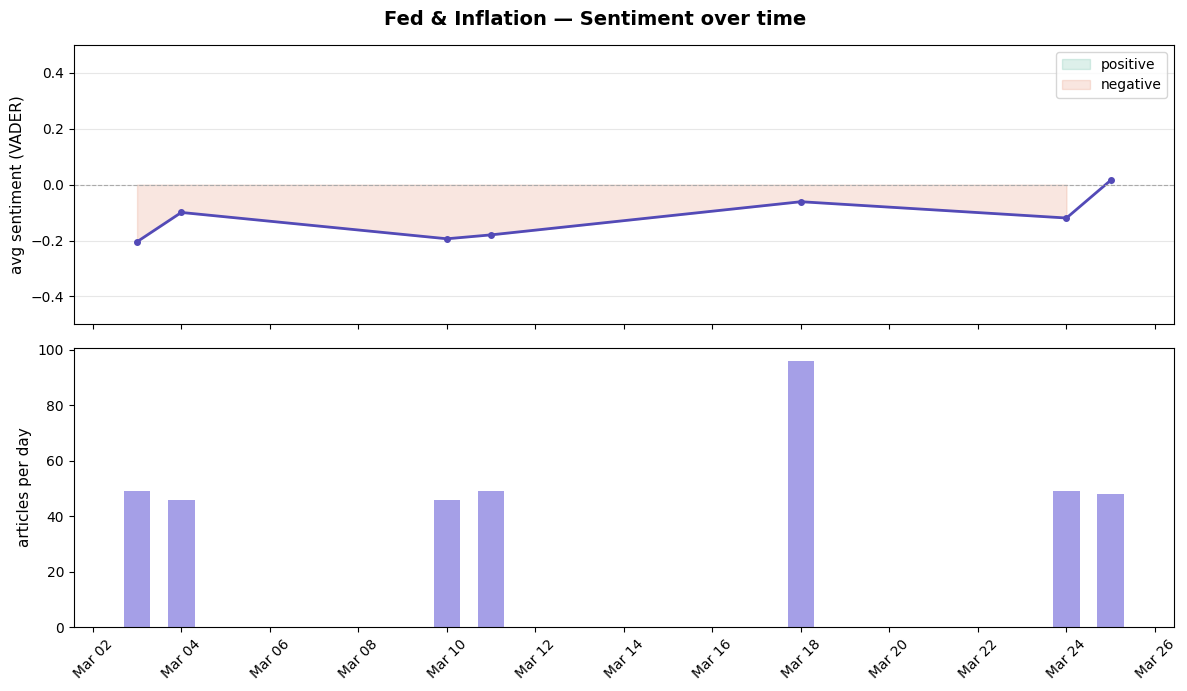

Chart saved as fed_sentiment.png


In [49]:
# Cell 5 — plot it
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
fig.suptitle("Fed & Inflation — Sentiment over time", fontsize=14, fontweight="bold")

# --- top chart: sentiment line ---
ax1.plot(daily["published"], daily["avg_sentiment"], color="#534AB7", linewidth=2, marker="o", markersize=4)
ax1.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax1.fill_between(
    daily["published"], daily["avg_sentiment"], 0,
    where=(daily["avg_sentiment"] >= 0), color="#1D9E75", alpha=0.15, label="positive"
)
ax1.fill_between(
    daily["published"], daily["avg_sentiment"], 0,
    where=(daily["avg_sentiment"] < 0),  color="#D85A30", alpha=0.15, label="negative"
)
ax1.set_ylabel("avg sentiment (VADER)", fontsize=11)
ax1.set_ylim(-0.5, 0.5)
ax1.legend(fontsize=10)
ax1.grid(axis="y", alpha=0.3)

# --- bottom chart: volume bars ---
ax2.bar(daily["published"], daily["article_count"], color="#7F77DD", alpha=0.7, width=0.6)
ax2.set_ylabel("articles per day", fontsize=11)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax2.xaxis.set_major_locator(mdates.DayLocator(interval=2))
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig("fed_sentiment.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved as fed_sentiment.png")